# Applying PCA in a real world dataset 

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df.shape

(42000, 785)

In [4]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
19512,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


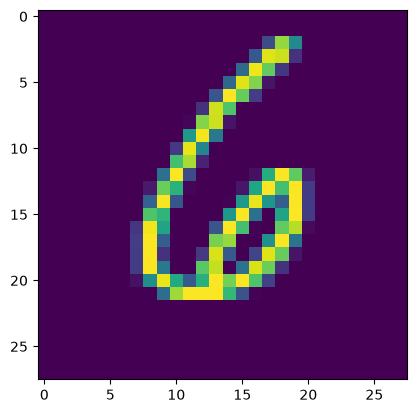

In [5]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[18973,1:].values.reshape(28,28))

In [6]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(33600, 784)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(X_train,y_train)
print("Model tarined successfull")

Model tarined successfull


In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score
print("accuracy_score for test",accuracy_score(y_test,y_pred))

accuracy_score for test 0.9648809523809524


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [13]:
X_train1 = scaler.fit_transform(X_train)
X_test1= scaler.transform(X_test)

In [14]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 400)

In [15]:
X_train1 = pca.fit_transform(X_train)
X_test1 = pca.transform(X_test)

In [16]:
X_train1.shape

(33600, 400)

In [17]:
knn = KNeighborsClassifier()
knn.fit(X_train1,y_train)
print('Model trained')


Model trained


In [18]:
y_pred1 = knn.predict(X_test1)
print('accuracy_score for test',accuracy_score(y_test,y_pred1))

accuracy_score for test 0.9661904761904762


In [ ]:
results = []

for i in range(1, 785):

    pca = PCA(n_components=i)

    X_train1 = pca.fit_transform(X_train)
    X_test1 = pca.transform(X_test)

    knn = KNeighborsClassifier()
    knn.fit(X_train1, y_train)

    y_pred1 = knn.predict(X_test1)

    accuracy = accuracy_score(y_test, y_pred1)

    results.append((i, accuracy))


best_components, best_accuracy = max(
    results,
    key=lambda x: x[1]
)

print("Best Components:", best_components)
print("Best Accuracy:", best_accuracy)

In [20]:
pca = PCA(n_components = 2)
X_train1 = pca.fit_transform(X_train)
X_test1 = pca.transform(X_test)

In [21]:
X_train1

array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]], shape=(33600, 2))

In [26]:
import plotly.express as px

y_train1 = y_train.astype(str)

fig = px.scatter(
    x=X_train1[:, 0],
    y=X_train1[:, 1],
    color=y_train1,
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.show()

In [31]:
pca = PCA(n_components = 3)
X_train2 = pca.fit_transform(X_train)
X_test2 = pca.transform(X_test)

In [32]:
X_train2

array([[-226.60523462, -305.89437099, -417.17563833],
       [  38.33583717,  461.09152047, -100.40840682],
       [-305.49225463,  351.67141678,  961.3475787 ],
       ...,
       [ -28.00133402, -596.06287179, -606.25130926],
       [ 233.97011308,  -18.64779077,  148.27481803],
       [1096.50373629,  254.72333173,  560.33354832]], shape=(33600, 3))

In [ ]:


y_train2 = y_train.astype(str)

fig = px.scatter_3d(
    x=X_train2[:, 0],
    y=X_train2[:, 1],
    z=X_train2[:, 2],
    color=y_train2
)

fig.update_layout(
    margin=dict(l=20, r=20, t=20, b=20)
)

fig.show()